In [ ]:
import polars as pl
from pathlib import Path
from textwrap import fill
import joblib
from glob import glob
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Point to the data/ directory at repo root (download S3 data there)
DATA_DIR = Path('../data')

site_mapping = {
    'bidmc':'BIDMC',
    'stan':'Stanford',
    'emory':'Emory',
    'bch':'BCH',
    'mgb':'MGB',
}
model_type_mapping = {
    'nt1':'NT1',
    'nt2ih':'NT2/IH',
    'nt12':'NT1/2/IH',
}

In [ ]:
features = pl.read_parquet(DATA_DIR / 'discriminative-modeling/features.parquet').hstack(
    pl.read_parquet(DATA_DIR / 'discriminative-modeling/notes.parquet').select('annot', 'cohort')
).filter(
    pl.col('annot') != 3 # unsure cases
).select(
    'id','date','cohort','annot', pl.all().exclude(['id','date','cohort','annot'])
)

In [ ]:
all_models = {}
for model_type in ['nt1', 'nt2ih']:#, 'nt12']:

    # Load all your models
    rf_models = {}
    xgb_models = {}
    gb_models = {}  # your current models
    logistic_models = {}

    results_dir = DATA_DIR / f'results/{model_type}_vs_others'

    for m in glob(str(results_dir / 'fold_models_LogisticRegression/*.pkl')):
        logistic_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_GradientBoosting/*.pkl')):
        gb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_RandomForest/*.pkl')):
        rf_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    for m in glob(str(results_dir / 'fold_models_XGBoost/*.pkl')):
        xgb_models[m.split('/')[-1].split('_')[-1].split('.')[0]] = joblib.load(m)

    # Compare all three
    model_comparison = {
        'GradientBoosting': gb_models,
        'RandomForest': rf_models,
        'XGBoost': xgb_models,
        'LogisticRegression': logistic_models,
    }

    all_models[model_type] = model_comparison


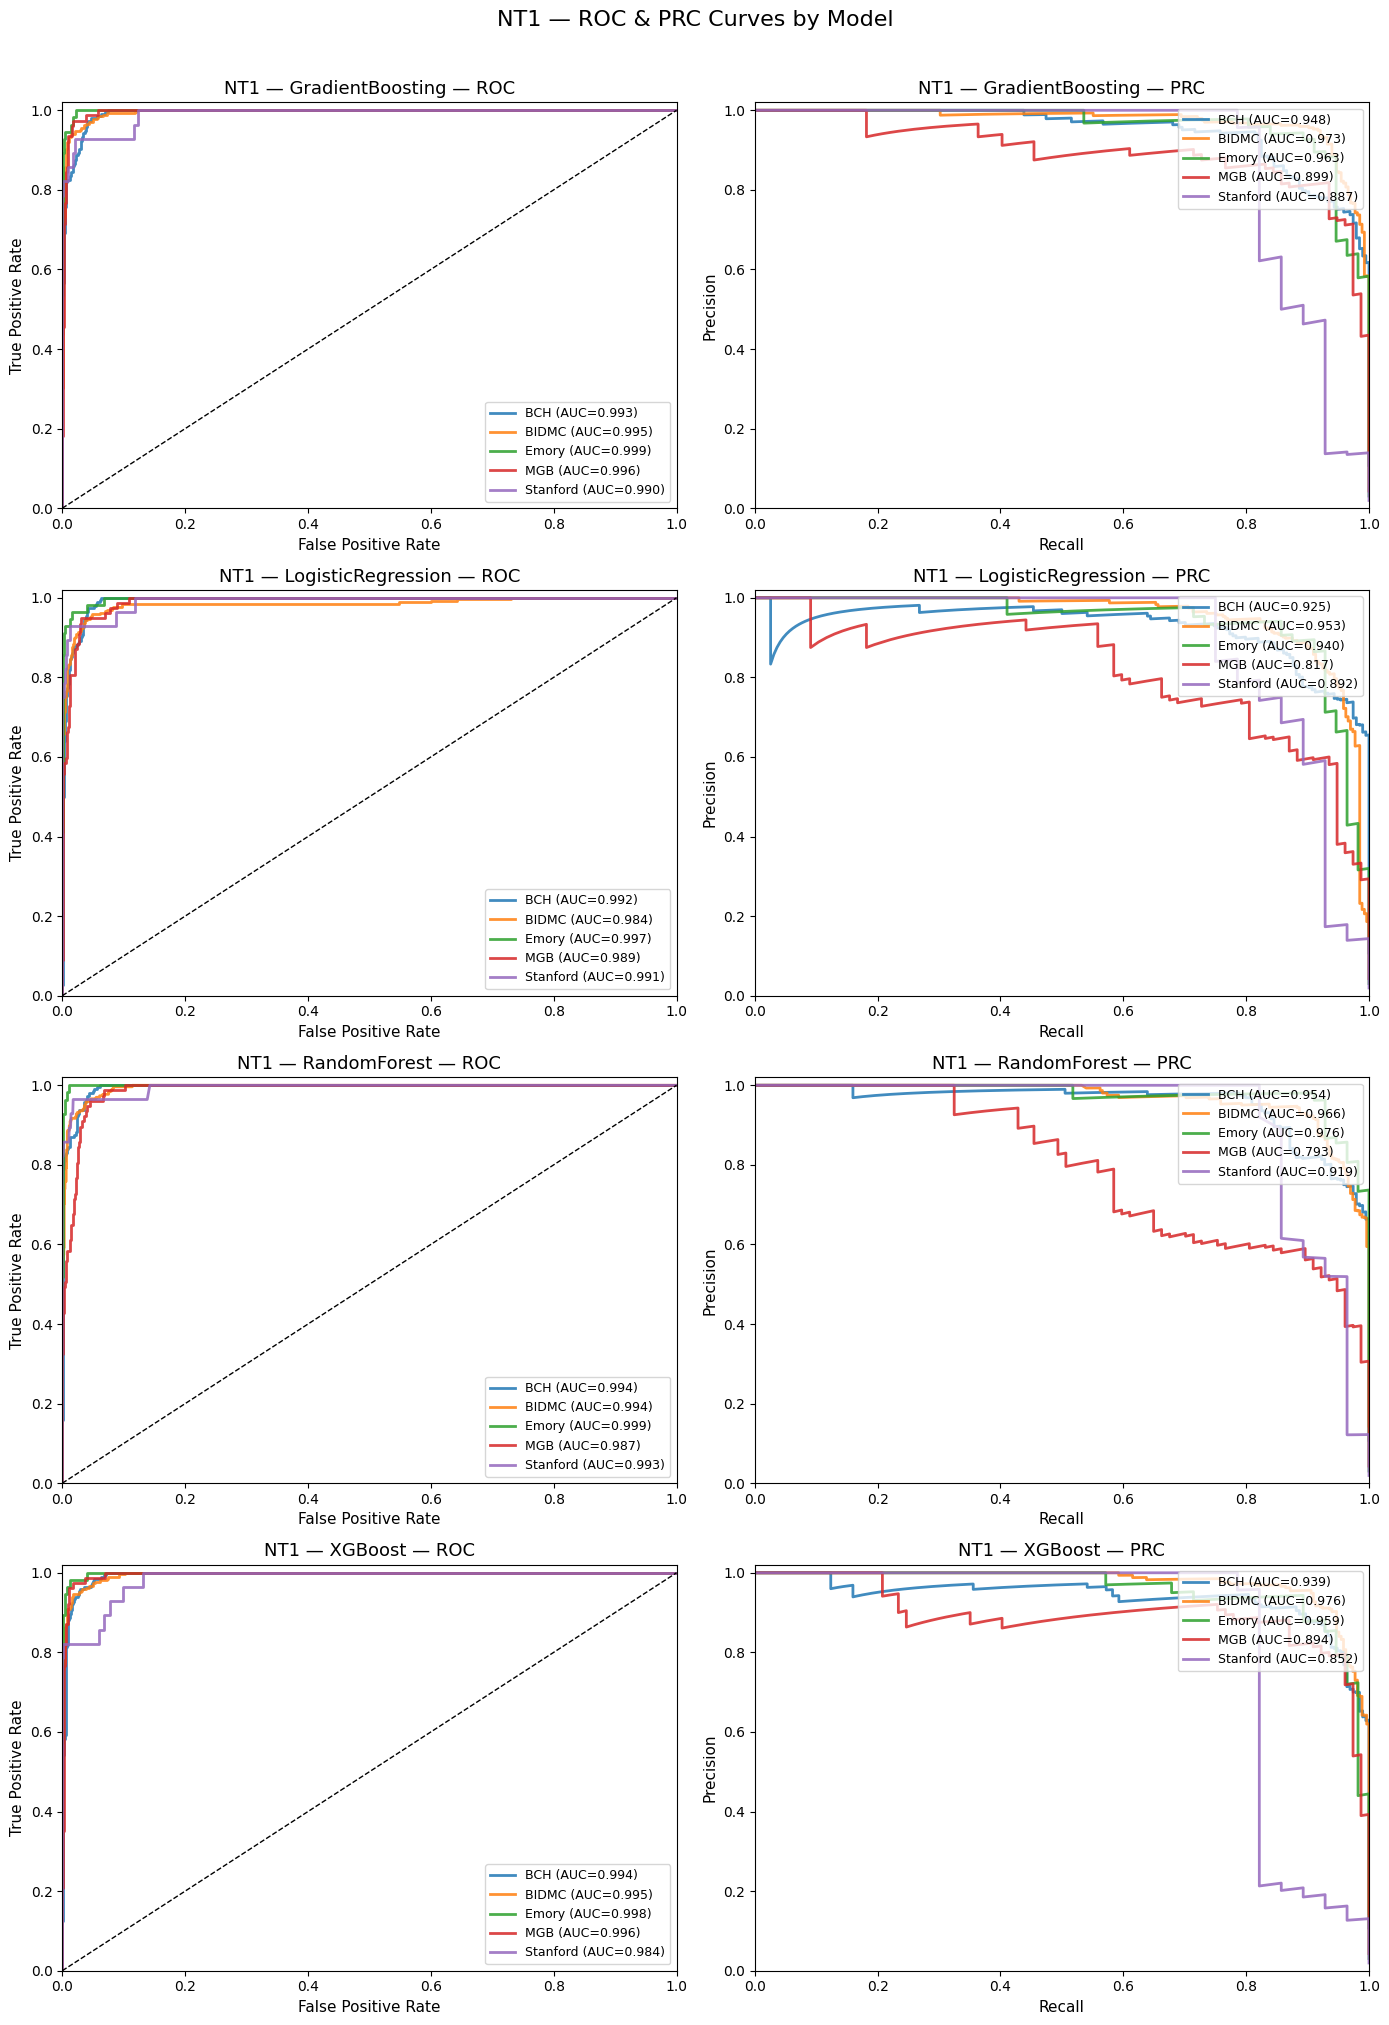

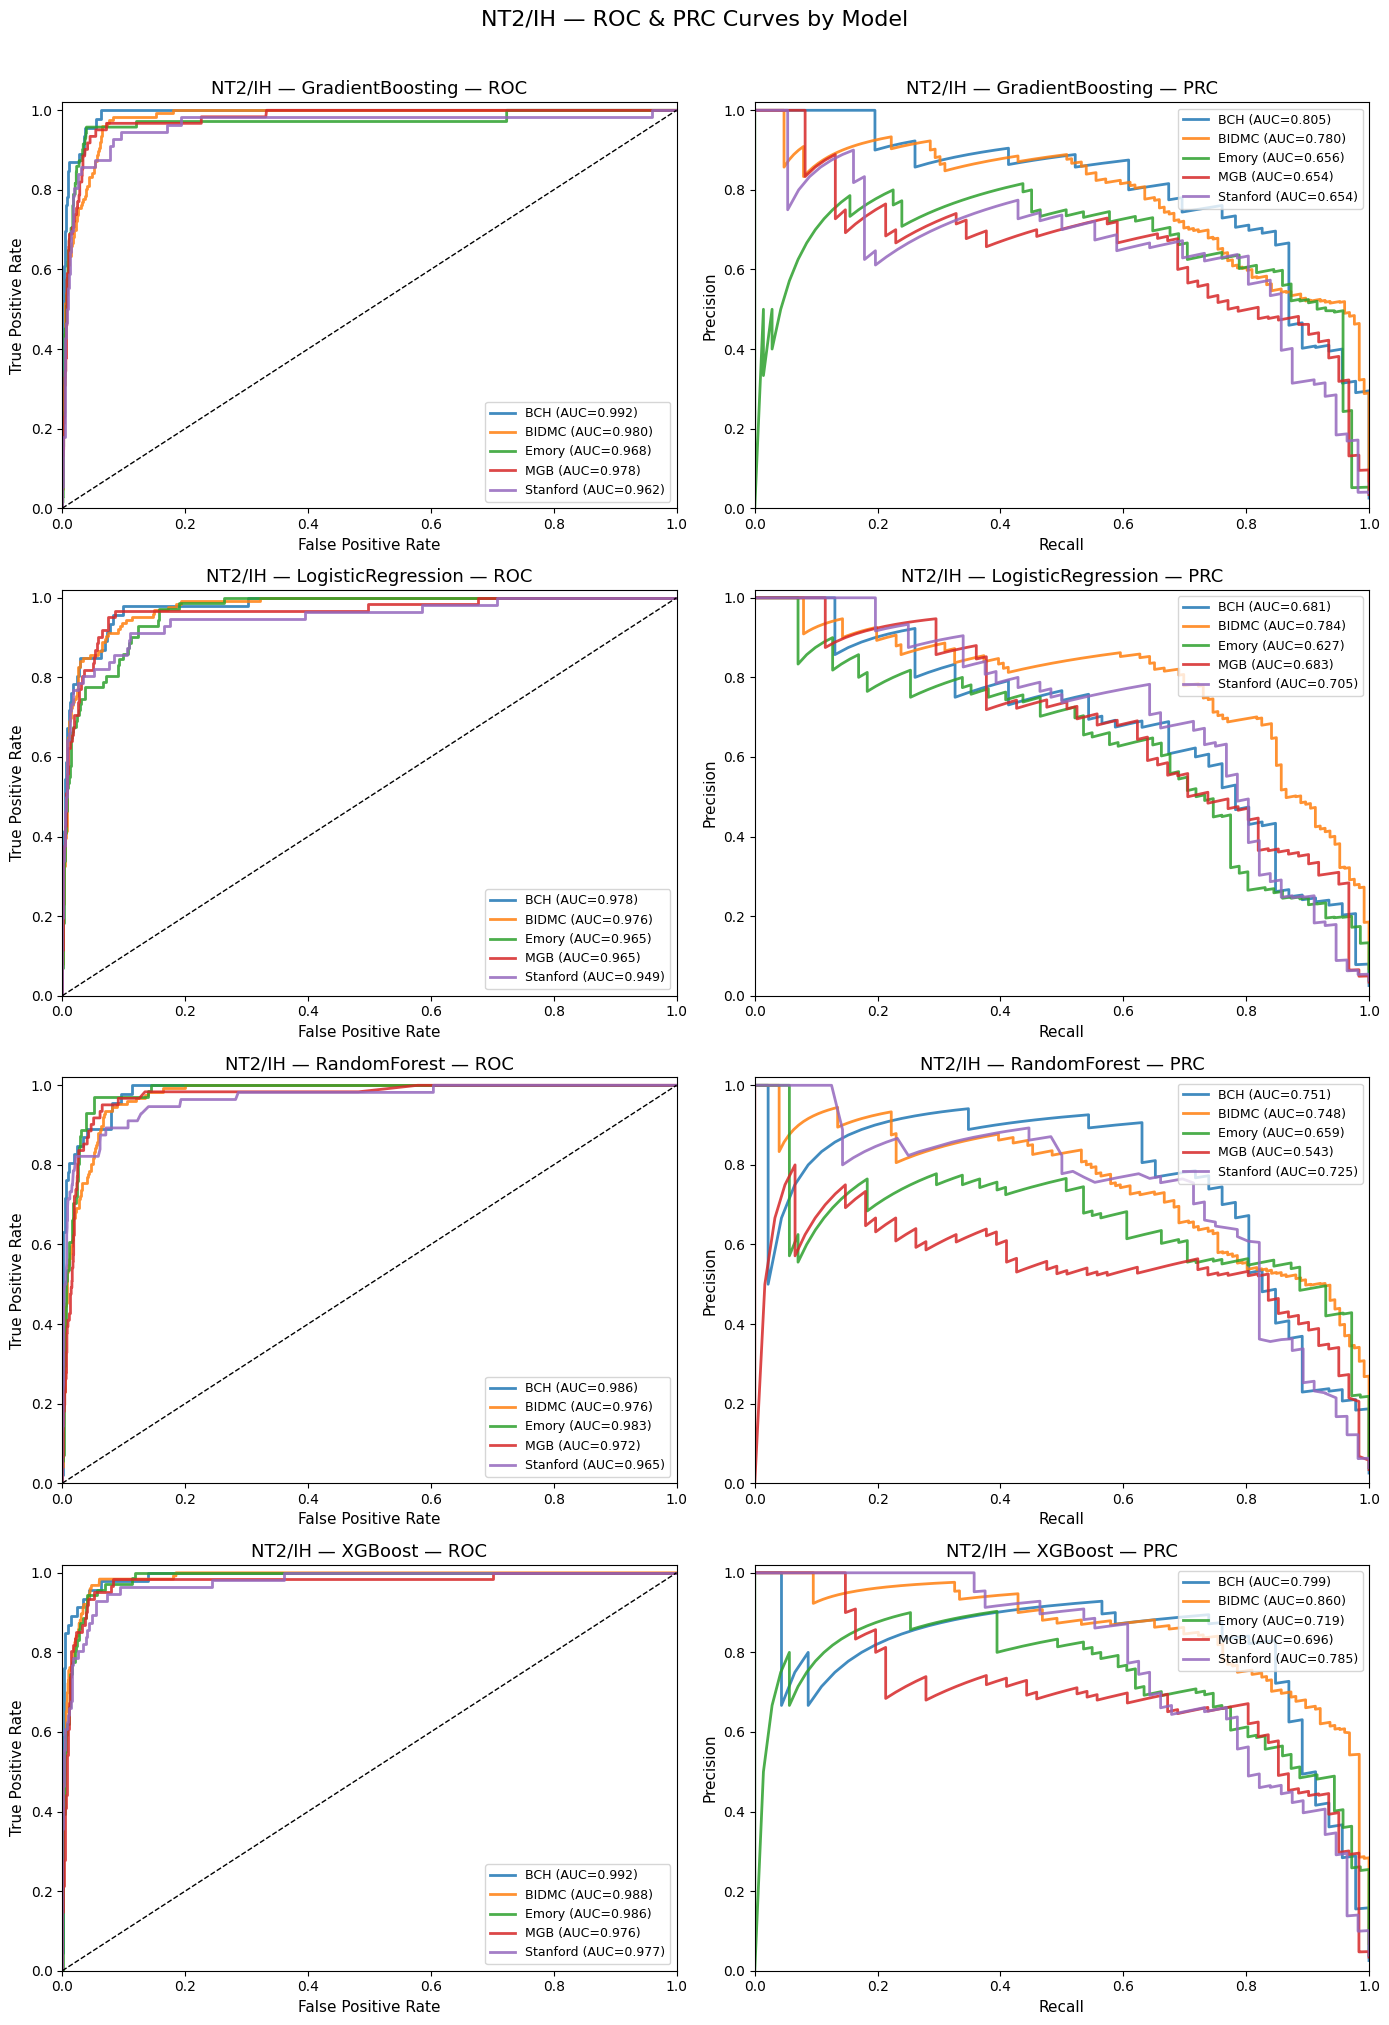

In [16]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

for model_type in ['nt1', 'nt2ih']:
    model_comparison = all_models[model_type]
    feat = features.clone()
    if model_type == 'nt1':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 1).then(1).otherwise(0).alias('nt1')
        )
    elif model_type == 'nt2ih':
        feat = feat.with_columns(
            pl.when(pl.col('annot') == 2).then(1).otherwise(0).alias('nt2ih')
        )
    label = model_type_mapping[model_type]
    
    model_names = sorted(model_comparison.keys())
    n_models = len(model_names)
    
    fig, axes = plt.subplots(n_models, 2, figsize=(14, 5 * n_models))
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    site_colors = {site: plt.cm.tab10.colors[i] for i, site in enumerate(sorted(list(model_comparison.values())[0].keys()))}
    
    for m_idx, model_name in enumerate(model_names):
        models = model_comparison[model_name]
        ax_roc = axes[m_idx, 0]
        ax_prc = axes[m_idx, 1]

        for test_site in sorted(models.keys()):
            test_feat = feat.filter(pl.col('cohort') == test_site)
            X_test = test_feat.drop(['annot', 'cohort', 'id', 'date',model_type])
            y_test = test_feat[model_type].to_numpy()

            y_prob = models[test_site].predict_proba(X_test)[:, 1]
            color = site_colors[test_site]

            fpr, tpr, _ = roc_curve(y_test, y_prob)
            roc_auc = auc(fpr, tpr)
            ax_roc.plot(fpr, tpr, color=color, alpha=0.85, linewidth=2,
                        label=f"{site_mapping[test_site]} (AUC={roc_auc:.3f})")

            precision, recall, _ = precision_recall_curve(y_test, y_prob)
            pr_auc = auc(recall, precision)
            ax_prc.plot(recall, precision, color=color, alpha=0.85, linewidth=2,
                        label=f"{site_mapping[test_site]} (AUC={pr_auc:.3f})")

        ax_roc.plot([0, 1], [0, 1], 'k--', linewidth=1)
        ax_roc.set_title(f'{label} — {model_name} — ROC', fontsize=13)
        ax_roc.set_xlabel('False Positive Rate', fontsize=11)
        ax_roc.set_ylabel('True Positive Rate', fontsize=11)
        ax_roc.legend(fontsize=9, loc='lower right')
        ax_roc.set_xlim([0, 1])
        ax_roc.set_ylim([0, 1.02])

        ax_prc.set_title(f'{label} — {model_name} — PRC', fontsize=13)
        ax_prc.set_xlabel('Recall', fontsize=11)
        ax_prc.set_ylabel('Precision', fontsize=11)
        ax_prc.legend(fontsize=9, loc='upper right')
        ax_prc.set_xlim([0, 1])
        ax_prc.set_ylim([0, 1.02])

    fig.suptitle(f'{label} — ROC & PRC Curves by Model', fontsize=16, y=1.01)
    plt.tight_layout()
    plt.show()
